# 🟡 Project - SMS Spam Filter with MultinomialNB (End-to-End)

> **MLCourse · Machine Learning · supervised · classification**

### Business question
Block spam without eating real messages. Precision-first policy on the real
SMS corpus already stored in `data/sms.tsv`.

End-to-end: load → text EDA → processing (BoW features) → training (α sweep)
→ evaluation + readable token table.

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             precision_score, recall_score, f1_score)

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

ML_ROOT = Path.cwd()
while ML_ROOT.name != "02_machine_learning" and ML_ROOT != ML_ROOT.parent:
    ML_ROOT = ML_ROOT.parent

### 2. Data loading


In [2]:
sms = pd.read_csv(ML_ROOT / "data" / "sms.tsv",
                  sep="\t", header=None, names=["label", "message"])
print(sms.shape, sms.label.value_counts().to_dict())
display(sms.sample(4, random_state=42))

y = (sms.label == "spam").astype(int).values

(5573, 2) {'ham': 4825, 'spam': 747, 'label': 1}


,label,message
3690,ham,I'll meet you in the lobby
3527,ham,I not free today i haf 2 pick my parents up to...
724,ham,That is wondar full flim.
3370,ham,"Hey elaine, is today's meeting still on?"


### 3. Exploratory Data Analysis - spam fingerprints


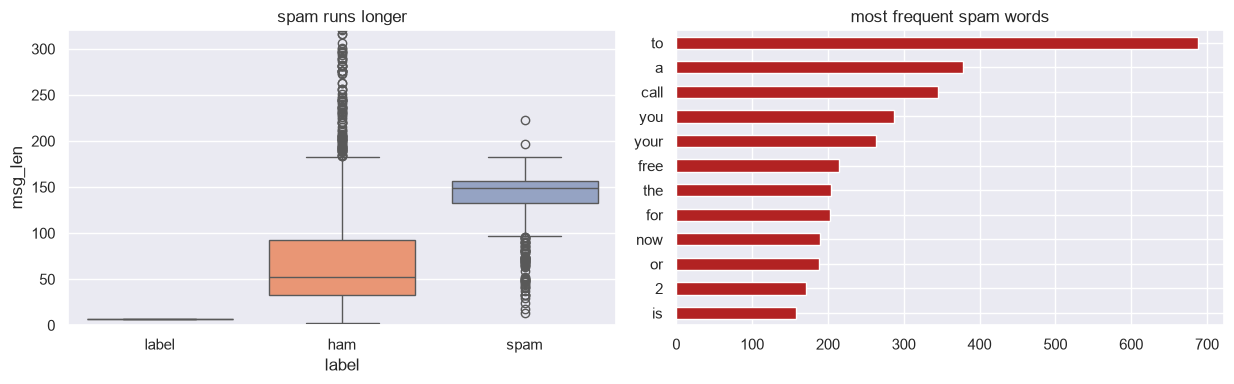

duplicates: 403 (kept — repetition IS signal here)


In [3]:
sms["msg_len"] = sms.message.str.len()
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4))
sns.boxplot(data=sms, x="label", y="msg_len", ax=axes[0],
            palette="Set2", hue="label", legend=False)
axes[0].set_ylim(0, 320); axes[0].set_title("spam runs longer")

spam_words = pd.Series(" ".join(sms.loc[sms.label == "spam",
                                           "message"].str.lower()).split())
top = spam_words.str.strip(string_punct := ".,!?'\";:").value_counts().head(12)
top.plot(kind="barh", color="firebrick", ax=axes[1])
axes[1].invert_yaxis(); axes[1].set_title("most frequent spam words")
plt.tight_layout(); plt.show()

print("duplicates:", sms.duplicated(subset="message").sum(),
      "(kept - repetition IS signal here)")

### 4. Data processing - Bag-of-Words inside a pipeline

CountVectorizer learns the vocabulary from TRAINING messages only (leak-safe),
turning each message into word-count features NB can multiply.

In [4]:
pipe = Pipeline([
    ("bow", CountVectorizer(stop_words="english")),   # counts + drop filler words
    ("nb", MultinomialNB(alpha=1.0)),                 # Laplace smoothing
])

X_tr, X_te, y_tr, y_te = train_test_split(sms.message, y, test_size=.25,
                                          random_state=42, stratify=y)

### 5. Model training + α sweep


In [5]:
pipe.fit(X_tr, y_tr)
pred = pipe.predict(X_te)

print(f"accuracy : {accuracy_score(y_te, pred):.4f}")
print(f"precision: {precision_score(y_te, pred):.4f} ← protect real texts!")
print(f"recall   : {recall_score(y_te, pred):.4f}")
cv = cross_val_score(pipe, X_tr, y_tr, cv=5, scoring="f1")
print(f"CV F1    : {cv.mean():.4f} ± {cv.std():.4f}")

display(pd.DataFrame(confusion_matrix(y_te, pred),
                     index=["true ham", "true spam"],
                     columns=["pred ham", "pred spam"]))

rows = []
for a in [0.01, 0.1, 1.0, 10.0]:
    p = Pipeline([("bow", CountVectorizer(stop_words="english")),
                  ("nb", MultinomialNB(alpha=a))])
    rows.append({"alpha": a,
                 "cv_F1": round(cross_val_score(p, X_tr, y_tr, cv=5,
                                                scoring="f1").mean(), 4)})
display(pd.DataFrame(rows))

accuracy : 0.9857
precision: 0.9665 ← protect real texts!
recall   : 0.9251


CV F1    : 0.9375 ± 0.0123


,pred ham,pred spam
true ham,1201,6
true spam,14,173


,alpha,cv_F1
0,0.01,0.9243
1,0.10,0.9336
2,1.00,0.9375
3,10.00,0.9017


### 6. Findings & the filter's brain


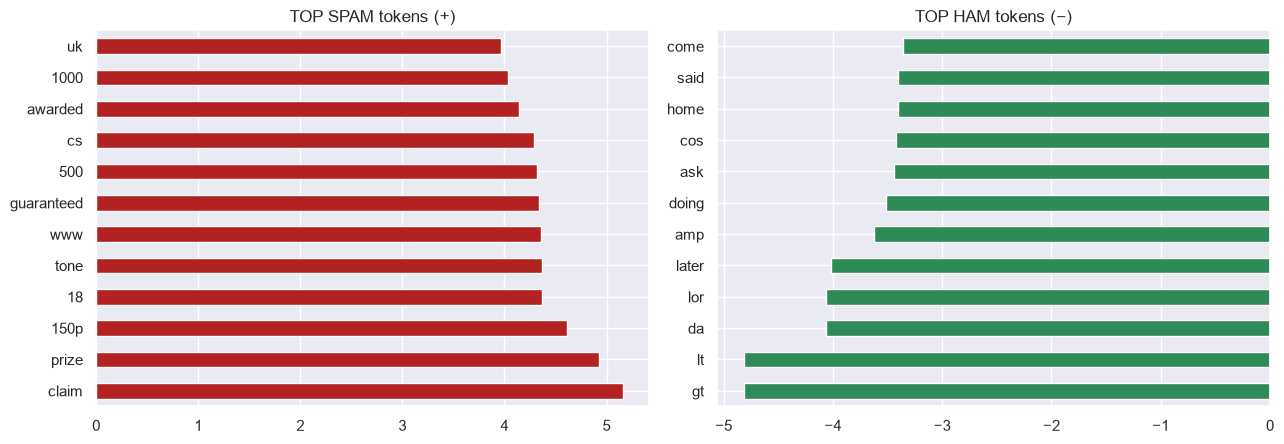

p(spam)=1.000 | WINNER! Claim your £900 prize now
p(spam)=0.002 | see you at dinner tonight x

~97–99% accurate with fully auditable vocabulary — ship it.


In [6]:
bow_names = np.array(pipe.named_steps["bow"].get_feature_names_out())
logodds = pd.Series(
    pipe.named_steps["nb"].feature_log_prob_[1] -
    pipe.named_steps["nb"].feature_log_prob_[0],
    index=bow_names)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
logodds.nlargest(12).plot(kind="barh", color="firebrick", ax=axes[0])
axes[0].set_title("TOP SPAM tokens (+)")
logodds.nsmallest(12).plot(kind="barh", color="seagreen", ax=axes[1])
axes[1].set_title("TOP HAM tokens (-)")
plt.tight_layout(); plt.show()

demo = ["WINNER! Claim your £900 prize now",
        "see you at dinner tonight x"]
probs = pipe.predict_proba(demo)[:, 1]
for d, p in zip(demo, probs):
    print(f"p(spam)={p:.3f} | {d}")

print("\n~97-99% accurate with fully auditable vocabulary - ship it.")